# Industrial Refrigeration Analysis — Part 3: Tuning Thermal Compensation

*A process-stability optimization, companion to the humidity study (Parts 1–2).*

The cooling system compensates for air temperature: as intake air warms and loses cooling
capacity, the system raises fan pressure to keep heat removal steady. The strength of that
response is set by a single compensation constant. Set it too low and cooling time still
drifts up with temperature; too high and it overshoots and drifts down. **Tuned correctly,
cooling time stays flat across temperature — which is the stability the process wants.**

This notebook builds the metric that measures that drift, and searches the compensation
constant for the value that minimises it.

> The method here was developed for, and applied to, real production machines. The specific
> machines, operating values, control formula, and the deployed setting are proprietary and
> are **not** reproduced. Everything below runs on synthetic data engineered to demonstrate
> the method; the numbers are illustrative, not real.

## 1. The idea: measure thermal sensitivity, then minimise it

Define **thermal sensitivity** as the slope of cooling time against temperature — `dTR/dT`,
in seconds per °C. It answers: *for each degree the air warms, how many seconds does cooling
time drift?*

- A **positive** slope means the system is *under-compensating* — hotter air, longer cooling.
- A **negative** slope means it is *over-compensating* — the pressure response overshoots and
  cooling time falls as it heats.
- A slope near **zero** is the goal: cooling time is stable regardless of temperature.

The compensation constant `K` sets where on that scale the system sits. So the optimisation is
direct: sweep `K`, measure `|dTR/dT|` at each, and pick the `K` that drives it to zero.

**Measuring the slope robustly.** Raw cooling-time data is noisy, so the slope is estimated
not on the raw scatter but on **conditional means**: temperature is grouped into 0.5 °C bins,
the mean cooling time per bin is computed, and the slope is regressed on those bin means. This
is more stable than a raw regression and is the metric used in the real study.

## 2. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
RNG = np.random.default_rng(3)
plt.rcParams["figure.dpi"] = 110

BIN_SIZE = 0.5        # °C — temperature bin width (as in the real study)
MIN_PER_BIN = 30      # drop sparsely populated bins before regressing

## 3. A synthetic operating period

We synthesise one operating period: air temperature varying over ~12 days (a slow weather
swing plus a daily cycle), and cooling time responding to it. Cooling time is modelled as a
baseline plus a temperature-dependent drift whose slope is `thermal_effect − compensation·K`
— under-compensation leaves a positive drift, over-compensation flips it negative. The
constants below are **invented** so the optimum falls at a value with no real-world meaning.

In [2]:
# ---- Synthetic response constants (fabricated; not real machine values) ----
THERMAL_EFFECT = 1.5     # s/°C that cooling time would drift with NO compensation
COMPENSATION   = 0.24    # s/°C removed per unit of K
TR_BASELINE    = 180.0   # s — synthetic mean cooling time (different from any real value)
NOISE_S        = 8.0     # s — measurement/process noise on cooling time
K_CURRENT      = 2.0     # the (synthetic) compensation currently set on the system

# ---- Temperature series over ~12 days at 1-minute cadence ----
n = 12 * 24 * 60
t_days = np.arange(n) / (24 * 60)
air_temp = (22.0
            + 7.0 * np.sin(2*np.pi * t_days / 12.0)      # slow weather swing
            + 4.0 * np.sin(2*np.pi * t_days)             # daily cycle
            + RNG.normal(0, 1.2, n))
T_REF = air_temp.mean()      # pivot; the system compensates around the period's central temp

def cooling_time(temp, K):
    """Synthetic cooling time given temperature and compensation constant K.
    Slope of TR vs temperature is (THERMAL_EFFECT - COMPENSATION*K)."""
    slope = THERMAL_EFFECT - COMPENSATION * K
    return TR_BASELINE + slope * (temp - T_REF) + RNG.normal(0, NOISE_S, len(temp))

# Data as the system currently runs (compensation = K_CURRENT)
df = pd.DataFrame({"air_temp_C": air_temp,
                   "cooling_time_s": cooling_time(air_temp, K_CURRENT)})
print(f"{len(df):,} readings | temperature {df.air_temp_C.min():.1f}–{df.air_temp_C.max():.1f} °C")
df.head()

17,280 readings | temperature 8.0–37.2 °C


,air_temp_C,cooling_time_s
0,24.449103,186.948447
1,18.953200,178.094013
2,22.541715,170.258125
3,21.378671,175.531937
4,21.536812,182.696097


## 4. Measuring thermal sensitivity (0.5 °C binning)

Group temperature into 0.5 °C bins, take mean cooling time per bin, and regress those means
on the bin centres. The slope is the sensitivity `dTR/dT`; a relative version (`%` of mean
cooling time per °C) is also reported, since a percentage is easier to compare across systems
than raw seconds.

In [3]:
def thermal_sensitivity(frame, temp_col="air_temp_C", tr_col="cooling_time_s"):
    """Return (slope_s_per_C, slope_pct_per_C, bin_table) via 0.5 °C conditional means."""
    f = frame[[temp_col, tr_col]].dropna().copy()
    f["T_bin"] = np.floor(f[temp_col] / BIN_SIZE) * BIN_SIZE + BIN_SIZE/2   # bin centre
    table = (f.groupby("T_bin")[tr_col]
               .agg(TR_mean="mean", TR_std="std", n="count")
               .reset_index())
    table = table[table["n"] >= MIN_PER_BIN].reset_index(drop=True)         # drop sparse bins
    slope, intercept, r, p, se = stats.linregress(table["T_bin"], table["TR_mean"])
    tr_period_mean = f[tr_col].mean()
    slope_pct = slope / tr_period_mean * 100
    return slope, slope_pct, intercept, table

slope0, slope0_pct, intercept0, bins0 = thermal_sensitivity(df)
print(f"Thermal sensitivity at current compensation (K = {K_CURRENT}):")
print(f"  dTR/dT = {slope0:+.3f} s/°C   ({slope0_pct:+.3f} % per °C)")
print(f"  bins used: {len(bins0)}")
bins0.head()

Thermal sensitivity at current compensation (K = 2.0):
  dTR/dT = +1.019 s/°C   (+0.566 % per °C)
  bins used: 50


,T_bin,TR_mean,TR_std,n
0,9.75,165.934754,7.279192,39
1,10.25,169.465819,8.068005,73
2,10.75,169.174532,7.242143,103
3,11.25,168.974704,7.282329,191
4,11.75,169.166203,8.335425,237


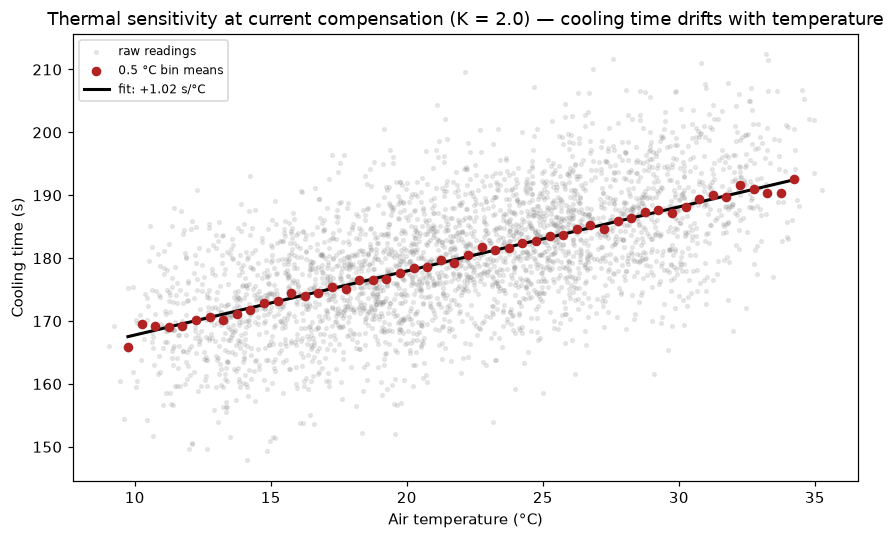

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
sample = df.sample(3000, random_state=0)
ax.scatter(sample.air_temp_C, sample.cooling_time_s, s=6, alpha=0.15, color="grey", label="raw readings")
ax.scatter(bins0.T_bin, bins0.TR_mean, s=28, color="firebrick", zorder=3, label="0.5 °C bin means")
xs = np.linspace(bins0.T_bin.min(), bins0.T_bin.max(), 50)
ax.plot(xs, intercept0 + slope0*xs, color="black", lw=2, label=f"fit: {slope0:+.2f} s/°C")
ax.set_xlabel("Air temperature (°C)"); ax.set_ylabel("Cooling time (s)")
ax.set_title(f"Thermal sensitivity at current compensation (K = {K_CURRENT}) — cooling time drifts with temperature")
ax.legend(fontsize=8); plt.tight_layout(); plt.show()

The raw scatter (grey) is noisy, but the 0.5 °C bin means (red) trace a clear upward line: at
the current compensation the system is **under-compensating**, and cooling time drifts up with
temperature. The binning is what makes that slope legible through the noise.

## 5. Optimising the compensation constant

Now sweep `K`. For each candidate value, regenerate cooling time under that compensation
(temperature held fixed, so only the compensation changes), measure the sensitivity with the
same binning method, and record `|dTR/dT|`. The minimum of that curve is the compensation that
flattens the system.

Compensation that minimises |dTR/dT|:  K ≈ 6.25  (synthetic optimum)


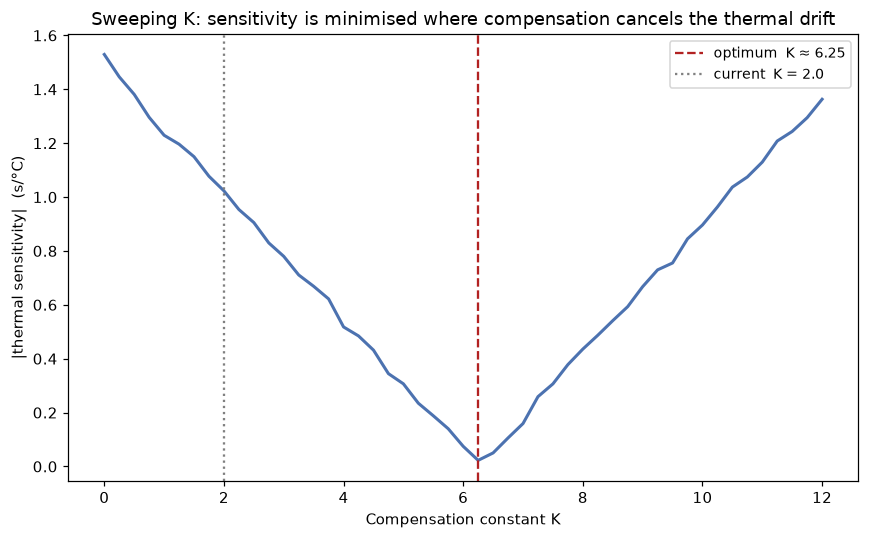

In [5]:
K_grid = np.arange(0.0, 12.01, 0.25)
sens = []
for K in K_grid:
    trial = pd.DataFrame({"air_temp_C": air_temp, "cooling_time_s": cooling_time(air_temp, K)})
    s, _, _, _ = thermal_sensitivity(trial)
    sens.append(s)
sens = np.array(sens)

K_opt = K_grid[np.argmin(np.abs(sens))]
print(f"Compensation that minimises |dTR/dT|:  K ≈ {K_opt:.2f}  (synthetic optimum)")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(K_grid, np.abs(sens), color="#4c72b0", lw=2)
ax.axvline(K_opt, ls="--", color="firebrick", label=f"optimum  K ≈ {K_opt:.2f}")
ax.axvline(K_CURRENT, ls=":", color="grey", label=f"current  K = {K_CURRENT}")
ax.set_xlabel("Compensation constant K"); ax.set_ylabel("|thermal sensitivity|  (s/°C)")
ax.set_title("Sweeping K: sensitivity is minimised where compensation cancels the thermal drift")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

The V-shaped curve is the whole result. To the left of the minimum the system
under-compensates (positive drift); to the right it over-compensates (negative drift); at the
floor, the temperature drift is cancelled and cooling time is stable. The current setting sits
on the under-compensated slope — there is clear room to move toward the optimum.

## 6. Before vs after

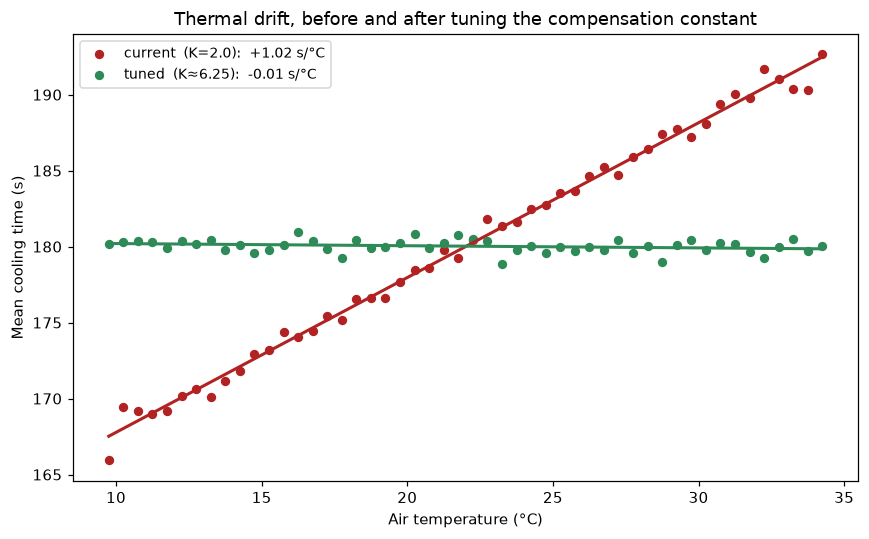

Sensitivity reduced from +1.019 s/°C to -0.014 s/°C (1% of the original magnitude).


In [6]:
df_opt = pd.DataFrame({"air_temp_C": air_temp, "cooling_time_s": cooling_time(air_temp, K_opt)})
s_before, sp_before, b_before, bins_b = thermal_sensitivity(df)
s_after,  sp_after,  b_after,  bins_a = thermal_sensitivity(df_opt)

fig, ax = plt.subplots(figsize=(8, 5))
xs = np.linspace(bins_b.T_bin.min(), bins_b.T_bin.max(), 50)
ax.scatter(bins_b.T_bin, bins_b.TR_mean, s=26, color="firebrick", label=f"current  (K={K_CURRENT}):  {s_before:+.2f} s/°C")
ax.plot(xs, b_before + s_before*xs, color="firebrick", lw=2)
ax.scatter(bins_a.T_bin, bins_a.TR_mean, s=26, color="seagreen", label=f"tuned  (K≈{K_opt:.2f}):  {s_after:+.2f} s/°C")
ax.plot(xs, b_after + s_after*xs, color="seagreen", lw=2)
ax.set_xlabel("Air temperature (°C)"); ax.set_ylabel("Mean cooling time (s)")
ax.set_title("Thermal drift, before and after tuning the compensation constant")
ax.legend(fontsize=9); plt.tight_layout(); plt.show()

print(f"Sensitivity reduced from {s_before:+.3f} s/°C to {s_after:+.3f} s/°C "
      f"({abs(s_after)/abs(s_before)*100:.0f}% of the original magnitude).")

The tuned line is nearly flat: cooling time no longer tracks temperature, which is exactly the
process stability the compensation exists to provide.

## 7. Conclusion

Thermal sensitivity — the slope of cooling time against temperature, estimated on 0.5 °C
conditional means — turns process stability into a single number that can be optimised.
Sweeping the compensation constant traces a clear minimum: the value at which temperature drift
is cancelled and cooling time holds steady. The method needs no assumptions about the control
hardware beyond the shape of its response, and it produces both a diagnosis (how far the current
setting is from optimal) and a target (where to move it).

Applied to real production machines during the internship, this method identified a compensation
update that measurably reduced thermal sensitivity. The specific systems, values, and the
deployed setting are proprietary and are not reproduced here; this notebook demonstrates the
method on synthetic data. Together with the humidity study (Parts 1–2), it reflects the same
approach throughout: build a transparent, reproducible metric, and let it drive the decision.